In [1]:
import sys
print(sys.executable)

/opt/miniconda3/bin/python


In [2]:
!{sys.executable} -m ensurepip --upgrade
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /tmp/tmp14gfeew_
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import os

In [4]:
"""
* Performs k-fold cross validation on the input data and labels.

* Parameters:
    k: The number of folds to split the data into.
    inputs: The input data.
    labels: The labels for the input data.

* Returns:
    A list of batches, where each
    batch is a list of tuples containing
    the input data and its corresponding label.
"""
def k_fold_cross_validation_split(k, inputs, labels):
  batches = []

  input_array = np.array(inputs)
  label_array = np.array(labels)
  batch_size = len(input_array) // k
  remaining_data = len(input_array) % k

  for i in range(k):
    batch = []

    print(f'\n-----------------Batch {i + 1} of {k}-----------------')

    for j in range(batch_size):
      index = i * batch_size + j
      batch.append((input_array[index], label_array[index]))

      if j == (batch_size // 4):
        print(f'Added {j + 1} data points to this batch.')
      elif j == (batch_size // 2):
        print(f'Added {j + 1} data points to this batch.')
      elif j == (batch_size * 3 // 4):
        print(f'Added {j + 1} data points to this batch.')

    print(f'Added {batch_size} data points to this batch.')
    batches.append(batch)

  for i in range(len(input_array) - remaining_data, len(input_array)):
    batches[len(batches) - 1].append((input_array[i], label_array[i]))

  if remaining_data > 0:
    print(f'Added {batch_size + remaining_data} data points to the last batch.')

  return batches

In [5]:
# Initialize a string containing the path to the training images.
training_path = "brain_mri_dataset/Training/"

# Initialize a string containing the path to the testing images.
testing_path = "brain_mri_dataset/Testing/"

# Initialize a list containing the four possible labels.
labels = ["glioma", "meningioma", "notumor", "pituitary"]

# Initialize a list to contain the training images.
training_images = []

# Initialize a list containing the testing images.
testing_images = []

# Iterate through the labels.
for label in labels:

    # Set a variable to the directory of a label's training images.
    label_dir = training_path + label

    # Iterate over the images of the current label.
    for image in os.listdir(label_dir):

        # Skip the file if its is called .ipynb_checkpoints
        if image == ".ipynb_checkpoints":
            continue

        # Store the relative path to a specific image.
        image_path = label_dir + "/" + image

        # Add the relative path to the list of training images.
        training_images.append(image_path)

    # Set a variable to the directory of a label's testing images.
    label_dir = testing_path + label

    # Iterate over the images of the current label.
    for image in os.listdir(label_dir):

        # Skip the file if its is called .ipynb_checkpoints
        if image == ".ipynb_checkpoints":
            continue

        # Store the relative path to a specific image.
        image_path = label_dir + "/" + image

        # Add the relative path to the list of testing images.
        testing_images.append(image_path)

In [6]:
# Shuffle the list of training images.
random.shuffle(training_images)

# Shuffle the list of testing images.
random.shuffle(testing_images)

In [7]:
# Initialize a list to store the label of each corresponding training image.
training_labels = []

testing_labels = []

# Iterate over the training images and extract its label.
for image in training_images:
    if "glioma" in image:
        training_labels.append("glioma")
    elif "meningioma" in image:
        training_labels.append("meningioma")
    elif "notumor" in image:
        training_labels.append("notumor")
    else:
        training_labels.append("pituitary")

for image in testing_images:
    if "glioma" in image:
        testing_labels.append([1,0,0,0])
    elif "meningioma" in image:
        testing_labels.append([0,1,0,0])
    elif "notumor" in image:
        testing_labels.append([0,0,1,0])
    else:
        testing_labels.append([0,0,0,1])

In [8]:
# Tune the value of k to split the training data into k batches.
k = 50

# Perform k-fold cross validation on the training data.
training_batches = k_fold_cross_validation_split(k, training_images, training_labels)


-----------------Batch 1 of 50-----------------
Added 29 data points to this batch.
Added 58 data points to this batch.
Added 86 data points to this batch.
Added 114 data points to this batch.

-----------------Batch 2 of 50-----------------
Added 29 data points to this batch.
Added 58 data points to this batch.
Added 86 data points to this batch.
Added 114 data points to this batch.

-----------------Batch 3 of 50-----------------
Added 29 data points to this batch.
Added 58 data points to this batch.
Added 86 data points to this batch.
Added 114 data points to this batch.

-----------------Batch 4 of 50-----------------
Added 29 data points to this batch.
Added 58 data points to this batch.
Added 86 data points to this batch.
Added 114 data points to this batch.

-----------------Batch 5 of 50-----------------
Added 29 data points to this batch.
Added 58 data points to this batch.
Added 86 data points to this batch.
Added 114 data points to this batch.

-----------------Batch 6 of 5

ValueError: num must be an integer with 1 <= num <= 20, not 21

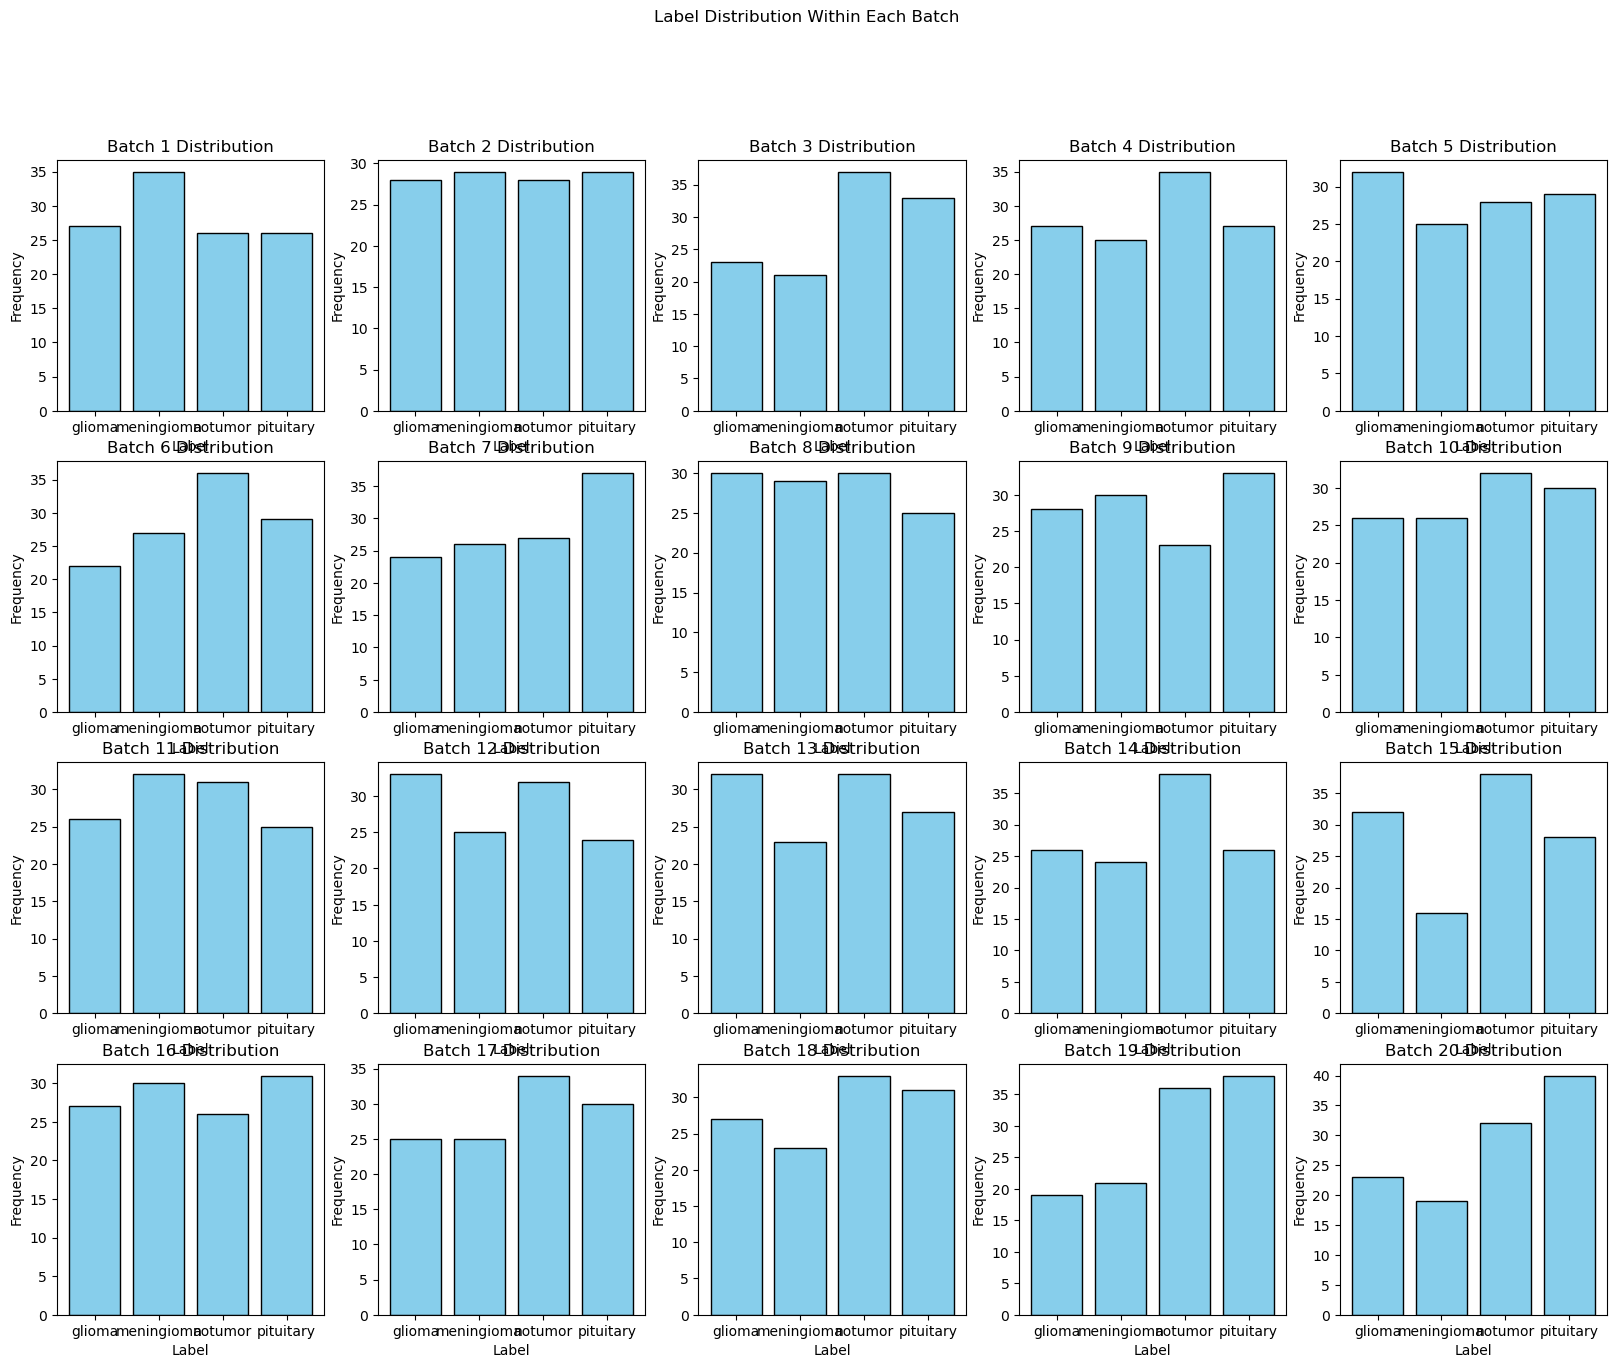

In [9]:
# Plot the distribution of the labels within each batch.
plt.figure(figsize=(20, 15))
plt.suptitle("Label Distribution Within Each Batch")

# Iterate over the batches.
for i in range(len(training_batches)):

    # Initialize a dictionary to keep track of the count of each label in the current batch.
    label_counts = dict({})

    # Iterate over the images in the current batch and count the labels.
    for image in training_batches[i]:
        if image[1] in label_counts:
            label_counts[image[1]] += 1
        else:
            label_counts[image[1]] = 1

    # Extract the counts for each label into a list.
    counts = [
        label_counts[labels[0]],
        label_counts[labels[1]],
        label_counts[labels[2]],
        label_counts[labels[3]]
    ]

    # Plot the distribution of each batch.
    plt.subplot(4, 5, i + 1)
    plt.bar(labels, counts, edgecolor="black", color="skyblue")
    plt.xlabel("Label")
    plt.ylabel("Frequency")
    plt.title("Batch " + str(i + 1) + " Distribution")

plt.tight_layout()

In [10]:
torch.manual_seed(42)

class BenchmarkNN(nn.Module):
    def __init__(self):
        super(BenchmarkNN, self).__init__()

        # Convolutional Layers
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=6,
            kernel_size=7,
            stride=1,
            padding=0
        )
        self.conv2 = nn.Conv2d(
            in_channels=6,
            out_channels=4,
            kernel_size=10,
            stride=10,
            padding=0
        )
        self.conv3 = nn.Conv2d(
            in_channels=4,
            out_channels=1,
            kernel_size=2,
            stride=1,
            padding=0
        )
        
        # Linear Layers
        self.layer1 = nn.Linear(16, 8)
        # self.layer2 = nn.Linear(12, 8)
        self.layer2 = nn.Linear(8, 5)
        self.layer3 = nn.Linear(5, 4)

        # Activation Layers
        self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

        # 2D Activation Layers
        self.avg_pool = nn.AvgPool2d(
            kernel_size=5,
            stride=5
        )

        # Dropout Layer (For Training)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        print(x.shape)
        
        x = self.conv1(x)
        x = self.relu(x)

        print(x.shape)
        
        x = self.conv2(x)

        print(x.shape)
        
        x = self.avg_pool(x)

        print(x.shape)
        
        x = self.conv3(x)
        x = self.relu(x)

        print(x.shape)
        
        x = x.view(x.size(0), -1)

        x = self.layer1(x)
        x = self.relu(x)
        # x = self.dropout(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.layer3(x)
        x = self.relu(x)
        x = self.softmax(x)

        return x

In [129]:
model = BenchmarkNN()
learning_rate = 0.01
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [130]:
model.train()

training_accuracies = []
loss_values = []

for i in range(len(training_batches)):
    X = []
    y = []
    
    print("-------------------------------------TRAINING WITH BATCH " + str(i + 1) + "------------------------------------------------------")

    for j in range(len(training_batches[i])):
        img_path, img_label = training_batches[i][j]
        
        print("[" + str(j + 1) + "/" + str(len(training_batches[i])) + "] READING IMAGE: " + img_path)
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (256, 256))
        img = img.astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))
        X.append(img)
        y.append(labels.index(img_label))

    X = np.stack(X)
    X_tensor = torch.from_numpy(X).float()

    y_tensor = torch.tensor(y, dtype=torch.long)

    optimizer.zero_grad()
    predictions = model(X_tensor)

    print("No. of Batches:", len(X))
    print("predictions:", predictions.shape)  # (N, num_classes)
    print("targets:", y_tensor.shape)         # (N,)
    
    loss_value = loss(predictions, y_tensor)
    loss_value.backward()
    optimizer.step()

    predictions = predictions.detach().numpy()
    cnt = 0

    for i in range(len(predictions)):
        if np.argmax(predictions[i]) == y[i]:
            cnt += 1

    training_accuracies.append(cnt / len(predictions))
    loss_values.append(loss_value.item())

-------------------------------------TRAINING WITH BATCH 1------------------------------------------------------
[1/114] READING IMAGE: brain_mri_dataset/Training/meningioma/Tr-me_1059.jpg
[2/114] READING IMAGE: brain_mri_dataset/Training/notumor/Tr-no_0142.jpg
[3/114] READING IMAGE: brain_mri_dataset/Training/pituitary/Tr-pi_1401.jpg
[4/114] READING IMAGE: brain_mri_dataset/Training/pituitary/Tr-pi_0657.jpg
[5/114] READING IMAGE: brain_mri_dataset/Training/meningioma/Tr-me_0531.jpg
[6/114] READING IMAGE: brain_mri_dataset/Training/notumor/Tr-no_0162.jpg
[7/114] READING IMAGE: brain_mri_dataset/Training/notumor/Tr-no_0472.jpg
[8/114] READING IMAGE: brain_mri_dataset/Training/meningioma/Tr-me_0401.jpg
[9/114] READING IMAGE: brain_mri_dataset/Training/notumor/Tr-no_1140.jpg
[10/114] READING IMAGE: brain_mri_dataset/Training/notumor/Tr-no_0768.jpg
[11/114] READING IMAGE: brain_mri_dataset/Training/glioma/Tr-gl_1251.jpg
[12/114] READING IMAGE: brain_mri_dataset/Training/pituitary/Tr-pi_016

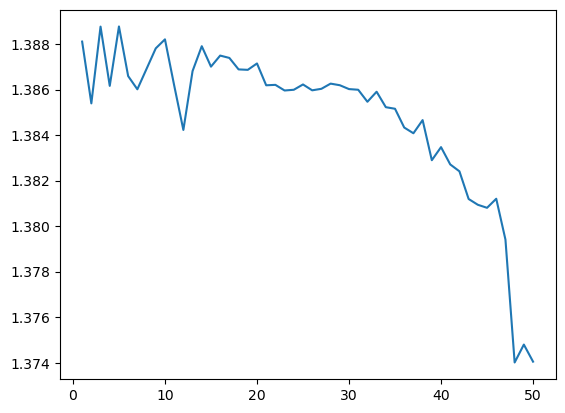

In [131]:
batch = list(range(1, 51))
plt.plot(batch, loss_values)

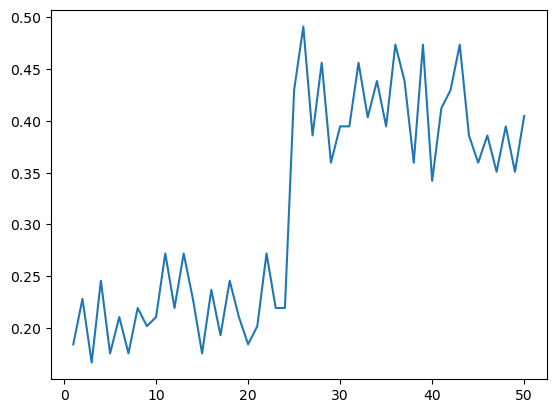

In [132]:
plt.plot(batch, training_accuracies)

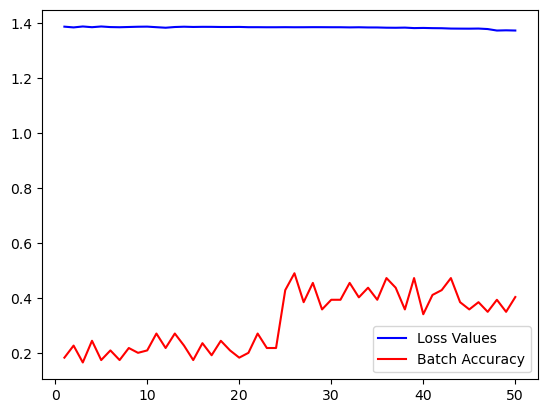

In [133]:
plt.plot(batch, loss_values, color="blue", label="Loss Values")
plt.plot(batch, training_accuracies, color="red", label="Batch Accuracy")
plt.legend()

In [12]:
model.eval()

X = []
y = []

for i in range(len(testing_images)):
    img_path = testing_images[i]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256))
    img = img.astype(np.float32) / 255.0
    img = np.transpose(img, (2, 0, 1))
    X.append(img)

    if 'glioma' in img_path:
        y.append(0)
    elif 'meningioma' in img_path:
        y.append(1)
    elif 'notumor' in img_path:
        y.append(2)
    else:
        y.append(3)

X = np.stack(X)
X_tensor = torch.from_numpy(X).float()
predictions = model(X_tensor)
predictions = predictions.detach().numpy()
cnt = 0

for i in range(len(predictions)):
    if np.argmax(predictions[i]) == y[i]:
        cnt += 1

print("Testing Accuracy: ", str(cnt / len(testing_images)))

torch.Size([1311, 3, 256, 256])
torch.Size([1311, 6, 250, 250])
torch.Size([1311, 4, 25, 25])
torch.Size([1311, 4, 5, 5])
torch.Size([1311, 1, 4, 4])
Testing Accuracy:  0.517162471395881


In [11]:
model = BenchmarkNN()
model.load_state_dict(torch.load("benchmark_model.pth", map_location="cpu"))

<All keys matched successfully>